In [13]:
import pandas as pd

wine = pd.read_csv('wine.csv')
wine

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0
...,...,...,...,...
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV,  RandomizedSearchCV
from scipy.stats import randint

# 1. 데이터 불러오기
wine = pd.read_csv("wine.csv")

# 2. 입력(X) / 정답(y) 나누기
# 컬럼 이름이 정확히 alcohol, sugar, pH, class 라고 가정
X = wine[['alcohol', 'sugar', 'pH']]
y = wine['class']

# 3. 훈련용 / 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)

# 스케일링 해주기
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # 훈련데이터로 기준 생성
X_test_scaled = scaler.transform(X_test)  

# 4. 모델만들기
model = DecisionTreeClassifier(max_depth=7, random_state=42 )


# 5. 교차검증
splitter = StratifiedKFold(n_splits=8, shuffle=True, random_state=42) #10 폴드로 나누는 분할기로 만듬
scores = cross_validate(model, X_train, y_train, cv=splitter)

# 그리드서치
params = {
    'min_impurity_decrease' :  np.arange(0.0001, 0.001, 0.0001),
    'max_depth' : range(5,20,1),
    'min_samples_split' : range(2, 100, 10)}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=1)

gs.fit(X_train_scaled, y_train)
dt = gs.best_estimator_
print(dt.score(X_train_scaled, y_train))
print(gs.best_params_)

# 랜덤서치
params2 = {
    'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
    'max_depth': randint(20, 50),
    'min_samples_split': randint(2, 25),
    'min_samples_leaf': randint(2, 25)
}

rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params2, n_jobs=1)

rs.fit(X_train_scaled, y_train)
dt2 = rs.best_estimator_
print(dt2.score(X_train_scaled, y_train))
print(rs.best_params_)

0.9623738669403112
{'max_depth': 19, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_split': 2}
0.9023430819223534
{'max_depth': 37, 'min_impurity_decrease': np.float64(0.0001), 'min_samples_leaf': 10, 'min_samples_split': 20}


정확도: 0.8569230769230769

분류 리포트:
              precision    recall  f1-score   support

         0.0       0.72      0.69      0.70       160
         1.0       0.90      0.91      0.91       490

    accuracy                           0.86       650
   macro avg       0.81      0.80      0.81       650
weighted avg       0.86      0.86      0.86       650



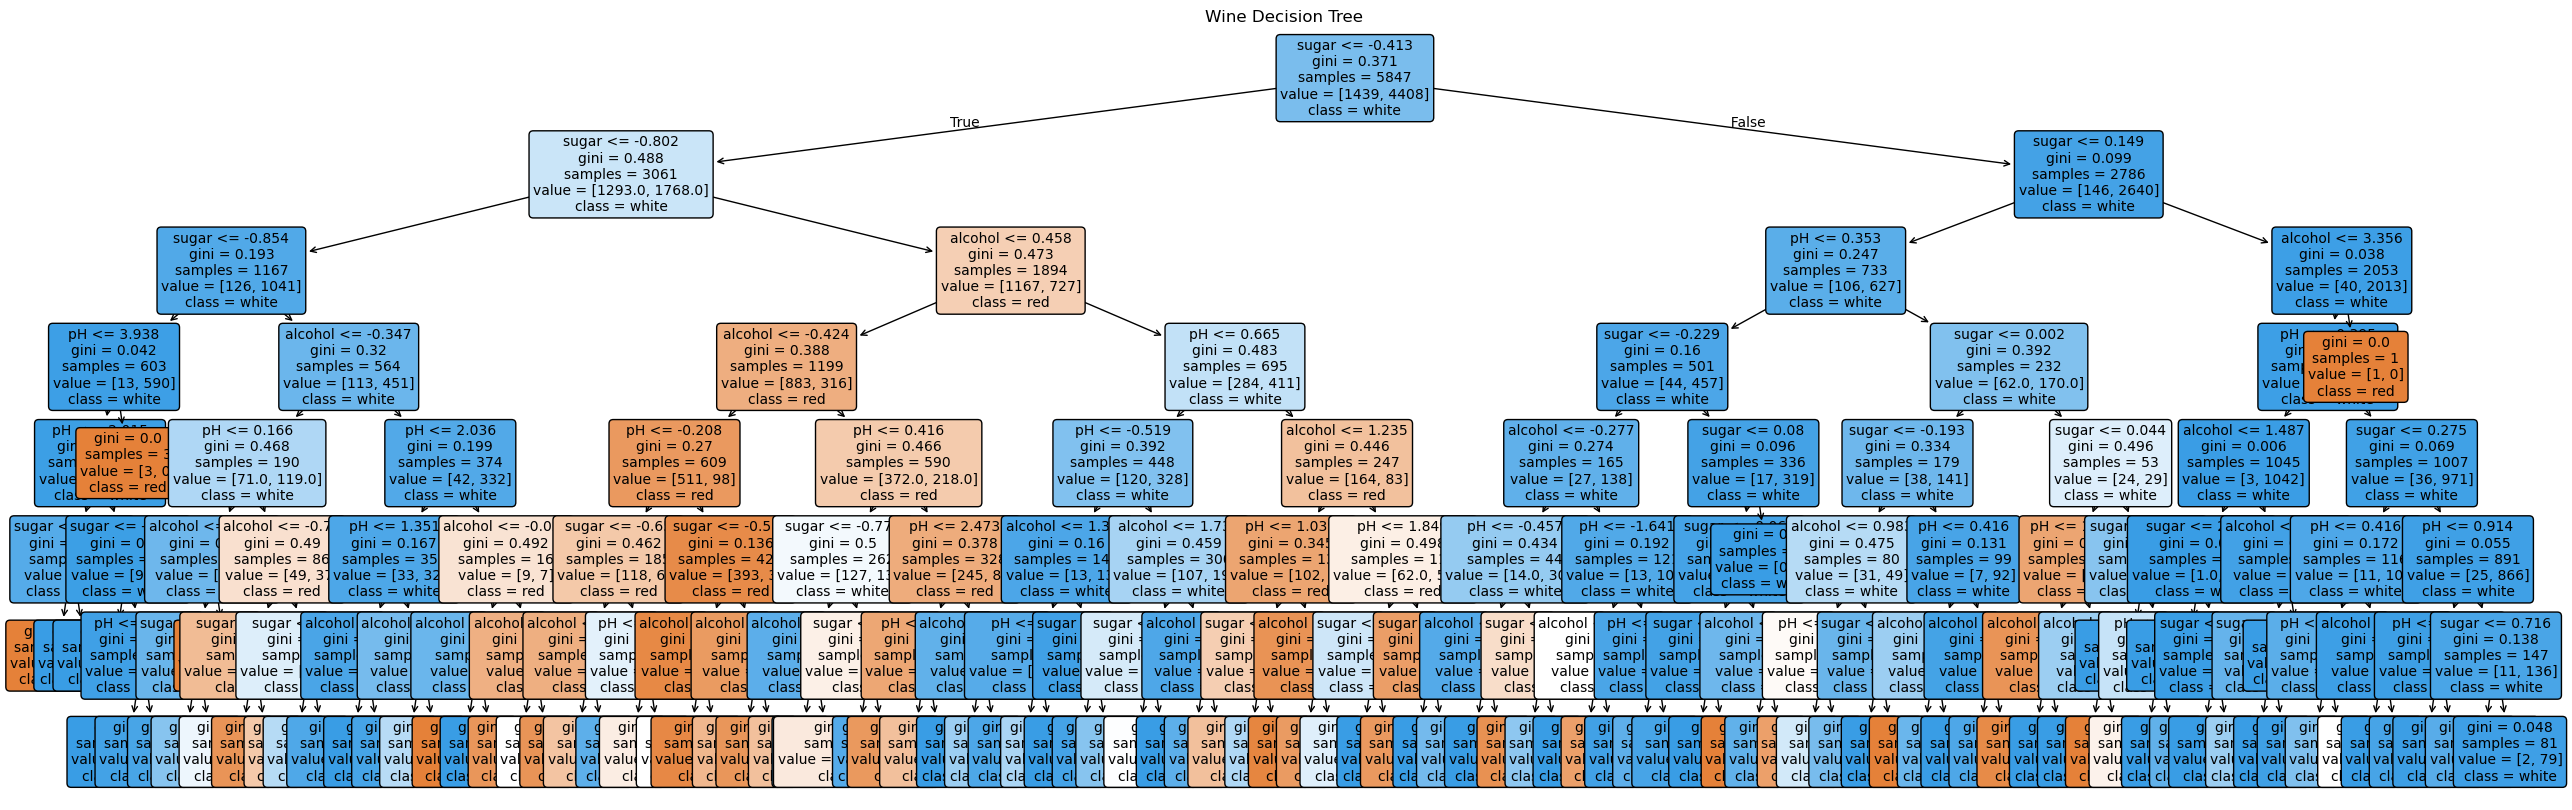

정확도 (Accuracy): 0.8569230769230769
정밀도 (Precision): 0.901010101010101
재현율 (Recall): 0.9102040816326531
F1 점수: 0.9055837563451776


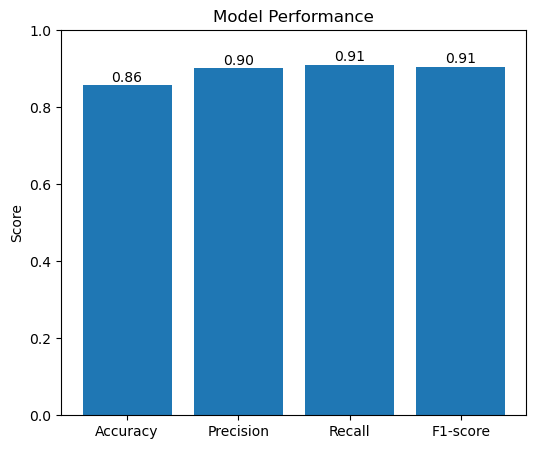

In [114]:

# 6. 학습
model.fit(X_train_scaled, y_train)

# 7. 예측
y_pred = dt.predict(X_test_scaled)

# 8. 정확도 확인
acc = accuracy_score(y_test, y_pred)
print("정확도:", acc)
print()
print("분류 리포트:")
print(classification_report(y_test, y_pred))

# 9. 트리 그림 그리기
plt.figure(figsize=(32, 10))
plot_tree(
    model,
    feature_names=['alcohol', 'sugar', 'pH'],
    class_names=['red', 'white'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Wine Decision Tree")
plt.show()

train_proba = model.predict_proba(X_train_scaled)
test_proba = model.predict_proba(X_test_scaled)

train_mean = train_proba.mean()
test_mean = test_proba.mean()
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("정확도 (Accuracy):", accuracy)
print("정밀도 (Precision):", precision)
print("재현율 (Recall):", recall)
print("F1 점수:", f1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 성능 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# 그래프
plt.figure(figsize=(6,5))
plt.bar(labels, scores)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


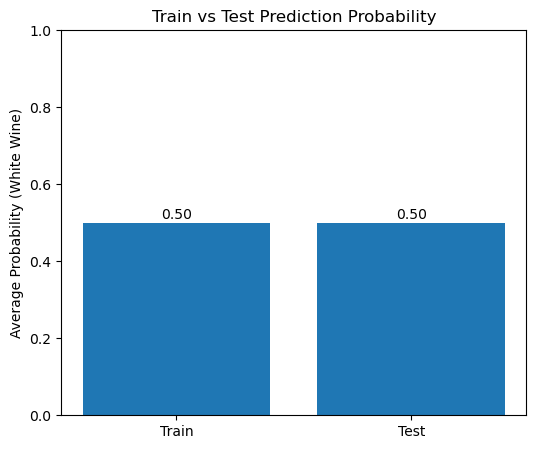

In [67]:
train_mean = train_proba.mean()
test_mean = test_proba.mean()

plt.figure(figsize=(6,5))

plt.bar(['Train','Test'], [train_mean, test_mean])

plt.ylim(0,1)
plt.ylabel("Average Probability (White Wine)")
plt.title("Train vs Test Prediction Probability")

plt.text(0, train_mean+0.01, f"{train_mean:.2f}", ha='center')
plt.text(1, test_mean+0.01, f"{test_mean:.2f}", ha='center')

plt.show()

정확도 (Accuracy): 0.8276923076923077
정밀도 (Precision): 0.867704280155642
재현율 (Recall): 0.9102040816326531
F1 점수: 0.8884462151394422


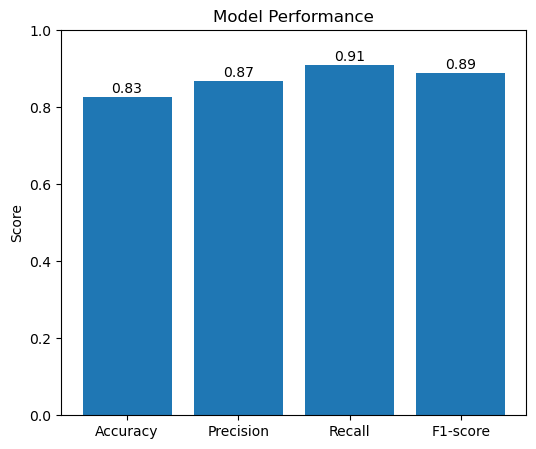

In [79]:
train_proba = model.predict_proba(X_train_scaled)
test_proba = model.predict_proba(X_test_scaled)

train_mean = train_proba.mean()
test_mean = test_proba.mean()
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("정확도 (Accuracy):", accuracy)
print("정밀도 (Precision):", precision)
print("재현율 (Recall):", recall)
print("F1 점수:", f1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 성능 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# 그래프
plt.figure(figsize=(6,5))
plt.bar(labels, scores)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()